In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [6]:
dataset = pd.read_csv("student_performance_prediction.csv")
dataset.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


In [7]:
dataset = dataset.drop(columns=["Student ID"])
dataset.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,12.5,NaN,75.0,Yes,Master,Yes
1,9.3,95.3,60.6,No,High School,No
2,13.2,NaN,64.0,No,Associate,No
3,17.6,76.8,62.4,Yes,Bachelor,No
4,8.8,89.3,72.7,No,Master,No


In [8]:
dataset.shape
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Study Hours per Week                         38005 non-null  float64
 1   Attendance Rate                              38008 non-null  float64
 2   Previous Grades                              38006 non-null  float64
 3   Participation in Extracurricular Activities  38000 non-null  str    
 4   Parent Education Level                       38000 non-null  str    
 5   Passed                                       38000 non-null  str    
dtypes: float64(3), str(3)
memory usage: 1.8 MB


In [9]:
dataset.isnull().sum()

Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64

In [10]:
dataset.isnull().sum()
print(dataset.shape)

(40000, 6)


In [11]:
dataset["Passed"] = dataset["Passed"].map({"Yes":1,"No":0})

In [12]:
dataset.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,12.5,NaN,75.0,Yes,Master,1.0
1,9.3,95.3,60.6,No,High School,0.0
2,13.2,NaN,64.0,No,Associate,0.0
3,17.6,76.8,62.4,Yes,Bachelor,0.0
4,8.8,89.3,72.7,No,Master,0.0


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

(array([6.0000e+00, 8.6000e+01, 7.9600e+02, 3.6800e+03, 9.1790e+03,
        1.1942e+04, 8.4650e+03, 3.0890e+03, 6.1100e+02, 1.5400e+02]),
 array([-14.3 ,   2.15,  18.6 ,  35.05,  51.5 ,  67.95,  84.4 , 100.85,
        117.3 , 133.75, 150.2 ]),
 <BarContainer object of 10 artists>)

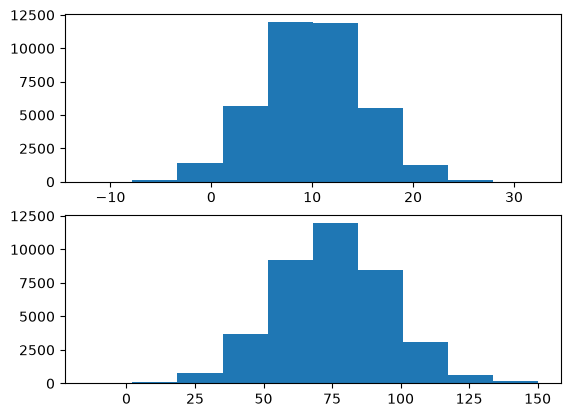

In [15]:
plt.subplot(2,1,1)
plt.hist(dataset["Study Hours per Week"])
plt.subplot(2,1,2)
plt.hist(dataset["Attendance Rate"])

In [16]:
dataset["Participation in Extracurricular Activities"].value_counts()

Participation in Extracurricular Activities
No     19028
Yes    18972
Name: count, dtype: int64

In [17]:
dataset["Parent Education Level"].value_counts()

Parent Education Level
Bachelor       7685
High School    7675
Doctorate      7610
Associate      7604
Master         7426
Name: count, dtype: int64

<Axes: xlabel='Passed', ylabel='Previous Grades'>

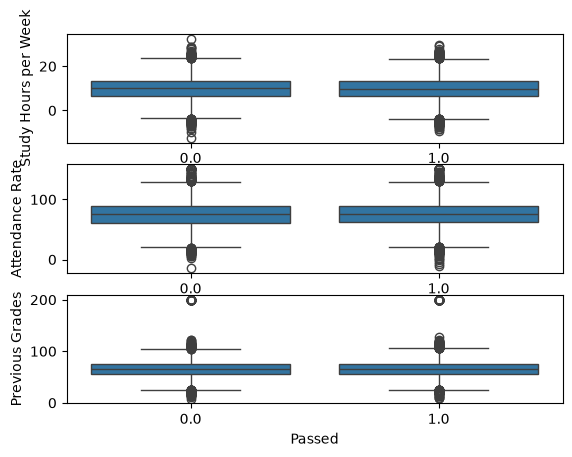

In [18]:

plt.subplot(3,1,1)
sns.boxplot(x = "Passed",y = "Study Hours per Week", data = dataset)
plt.subplot(3,1,2)
sns.boxplot(x = "Passed",y = "Attendance Rate", data = dataset)
plt.subplot(3,1,3)
sns.boxplot(x = "Passed",y = "Previous Grades", data = dataset)

<Axes: >

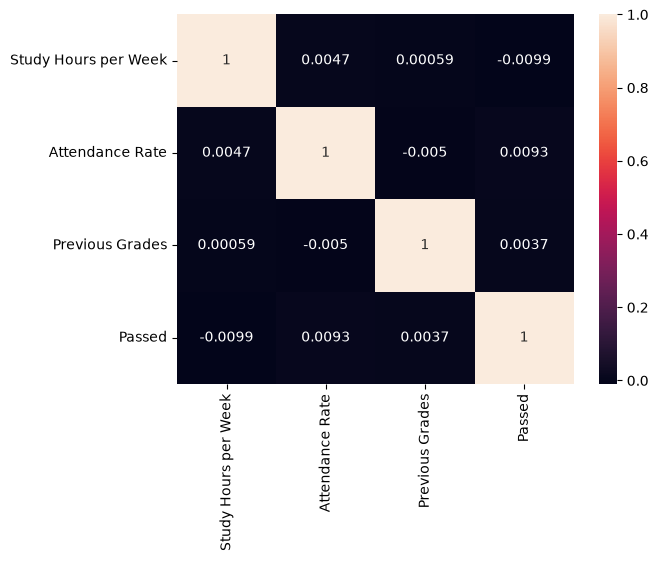

In [19]:
corr = dataset.corr(numeric_only = True)
sns.heatmap(corr,annot = True)

In [22]:
for col in num_cols:
    dataset[col] = dataset[col].fillna(dataset[col].median())

In [23]:
cat_cols = dataset.select_dtypes(include = "object").columns
for col in cat_cols:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

C:\Users\MUKUL KUMAR\AppData\Local\Temp\ipykernel_5632\1230028078.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = dataset.select_dtypes(include = "object").columns


In [24]:
dataset.isnull().sum()

Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64

In [25]:
dataset.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,12.5,75.3,75.0,Yes,Master,1.0
1,9.3,95.3,60.6,No,High School,0.0
2,13.2,75.3,64.0,No,Associate,0.0
3,17.6,76.8,62.4,Yes,Bachelor,0.0
4,8.8,89.3,72.7,No,Master,0.0


In [26]:
for col in num_cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dataset = dataset[
        (dataset[col] >= lower) &
        (dataset[col] <= upper)
    ]

In [27]:
dataset.shape

(38577, 6)

In [28]:
dataset["Participation in Extracurricular Activities"] = dataset["Participation in Extracurricular Activities"].map({"Yes":1,"No":0})


In [29]:
dataset = pd.get_dummies(
    dataset,
    columns=["Parent Education Level"],
    drop_first=True
)

In [30]:
dataset.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Passed,Parent Education Level_Bachelor,Parent Education Level_Doctorate,Parent Education Level_High School,Parent Education Level_Master
0,12.5,75.3,75.0,1,1.0,False,False,False,True
1,9.3,95.3,60.6,0,0.0,False,False,True,False
2,13.2,75.3,64.0,0,0.0,False,False,False,False
3,17.6,76.8,62.4,1,0.0,True,False,False,False
4,8.8,89.3,72.7,0,0.0,False,False,False,True


In [31]:
X = dataset.drop("Passed",axis = 1)
y = dataset["Passed"]


In [32]:
X.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level_Bachelor,Parent Education Level_Doctorate,Parent Education Level_High School,Parent Education Level_Master
0,12.5,75.3,75.0,1,False,False,False,True
1,9.3,95.3,60.6,0,False,False,True,False
2,13.2,75.3,64.0,0,False,False,False,False
3,17.6,76.8,62.4,1,True,False,False,False
4,8.8,89.3,72.7,0,False,False,False,True


In [33]:
y.head()

0    1.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Passed, dtype: float64

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "LogisticRegression" : LogisticRegression(random_state=42),
    "DecisionTreeClassifier" : DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42),
    "RandomForestClassifier" : RandomForestClassifier(n_estimators=100, random_state=42),
    "KNeighborsClassifier" : KNeighborsClassifier(n_neighbors=7),
    "SupportVectorClassifier" : SVC(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [38]:
from sklearn.metrics import accuracy_score

for name,model in models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)
    print(f'Accuracy for {name}: {accuracy*100:.3f}')

Accuracy for LogisticRegression: 52.411
Accuracy for DecisionTreeClassifier: 52.566
Accuracy for RandomForestClassifier: 49.948
Accuracy for KNeighborsClassifier: 50.804
Accuracy for SupportVectorClassifier: 52.346
